Para Verificar Performance da GPU Usar o Comando:

watch -n 1 amd-smi

## Modo do Script:

TRAIN: o modelo será treinado e o melhor registrado será salvo.

TEST: o modelo salvo será testado com o dataset de teste

BOTH: o modelo sera treinado, salvo e testado

In [1]:
SCRIPT_MODE = "BOTH" # "TRAIN", "TEST" ou "BOTH"
GENERATE_HISTOGRAM = False

# Setup do Projeto

In [2]:
import torch

# Setup Agnostic Code for GPU/CPU
if torch.cuda.is_available():
    device = 'cuda'
    print(f"CUDA está disponivel!\nDispositivo configurado para: {device}\nDevice count: {torch.cuda.device_count()}\nNome do dispositivo: {torch.cuda.get_device_name(0)}\nVersao do PyTorch: {torch.__version__}")
else:
    device = 'cpu'
    print(f"CUDA não está disponível.\nDispositivo configurado para: {device}\nVersao do PyTorch: {torch.__version__}")

CUDA está disponivel!
Dispositivo configurado para: cuda
Device count: 2
Nome do dispositivo: AMD Radeon RX 7800 XT
Versao do PyTorch: 2.9.1+rocm7.2.0.git7e1940d4


In [3]:
# Constantes
import os

DATA_PATH = '/home/jose-vitor/Documents/Cityscapes_Dataset/fine'

IM_HEIGHT = 512
IM_WIDTH = 1024
#IM_HEIGHT = 256
#IM_WIDTH = 512

#BATCH_SIZE = 64
BATCH_SIZE = 12
NUM_WORKERS = os.cpu_count() // 2
EPOCHS = 100
LEANING_RATE = 1e-4

NUM_CLASSES = 20 # Numero de classes do dataset, incluindo a classe de ignorar (void)

In [4]:
# Bibliotecas e imports
import custom_cityscapes as ccs
import custom_transforms as ctr
import custom_metrics as cmt
import model_builder as mb
import train_model as tr
from utils import *

from torchvision import datasets
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import optim
from kornia import losses
# Mais informacoes em https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html#torchmetrics.classification.MulticlassJaccardIndex
from torchmetrics.classification import MulticlassJaccardIndex # Jaccard Index eh a mesma coisa que IoU (Intersection over Union) e esse opjeto pode calcular tambem iIoU
from pathlib import Path
import json

/home/jose-vitor/Documents/pytorch_projects/Fast-SCNN/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparando o Dataset Cityscapes

In [5]:
ds_lables = ccs.CityscapesLables()

# Imprimindo informacoes relevantes
print(f"O dataset possui {len(ds_lables.id_names)} classes treinaveis:")
ds_lables.id_names

O dataset possui 20 classes treinaveis:


{0: 'road',
 1: 'sidewalk',
 2: 'building',
 3: 'wall',
 4: 'fence',
 5: 'pole',
 6: 'traffic light',
 7: 'traffic sign',
 8: 'vegetation',
 9: 'terrain',
 10: 'sky',
 11: 'person',
 12: 'rider',
 13: 'car',
 14: 'truck',
 15: 'bus',
 16: 'train',
 17: 'motorcycle',
 18: 'bicycle',
 19: 'ignore'}

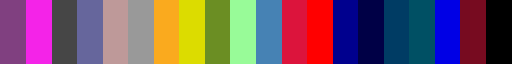

In [6]:
# Criando o colormap para as classes
cmap = ds_lables.get_cmap()
cmap

# Importar o Dataset Cityscapes

Definir Funções de Transform

In [7]:
custom_trans = ctr.Transforms(conv_size=(IM_HEIGHT, IM_WIDTH),
                              lable_conversion=ds_lables.lable_conversion)

Importar Dataset

In [8]:
train_dataset = ccs.AugmentedCityscapes(DATA_PATH,
                             split = 'train',
                             mode='fine',
                             target_type='semantic',
                             transform=custom_trans.train_transform,
                             target_transform=custom_trans.target_transform,
                             data_augmentation=custom_trans.data_augmentation)
val_dataset = datasets.Cityscapes(DATA_PATH,
                           split = 'val',
                           mode='fine',
                           target_type='semantic',
                           transform=custom_trans.val_transform,
                           target_transform=custom_trans.target_transform)
test_dataset = datasets.Cityscapes(DATA_PATH,
                            split = 'test',
                            mode='fine',
                            target_type='semantic',
                            transform=custom_trans.val_transform)

In [9]:
# Imprimir informacoes importantes dos datasets
img, smnt = train_dataset[0]
print(f"O Dataset de treino possui {len(train_dataset)} amostras.\n"
      f"O Dataset de validação possui {len(val_dataset)} amostras.\n"
      f"O Dataset de teste possui {len(test_dataset)} amostras.\n"
      f"Cada imagem posssui tamanho {img.shape} e tipo {img.dtype}, e cada mascara possui tamanho {smnt.shape} e tipo {smnt.dtype}.\n")

#print(f"Primeira Imagem do dataset de treino:\n{img}\nPrimenra mascara do dataset de treino:\n{smnt}")

O Dataset de treino possui 2975 amostras.
O Dataset de validação possui 500 amostras.
O Dataset de teste possui 1525 amostras.
Cada imagem posssui tamanho torch.Size([3, 512, 1024]) e tipo torch.float32, e cada mascara possui tamanho torch.Size([512, 1024]) e tipo torch.uint8.



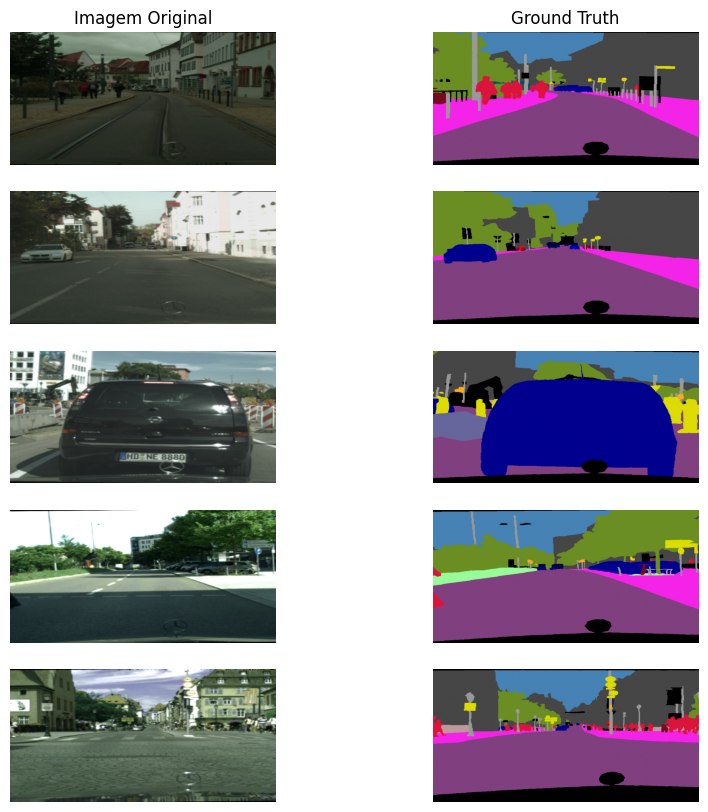

In [10]:
# Testando a funcao de exibicao
dataset_show(train_dataset, n=5, cmap=cmap)

In [11]:
# Gerar lista com pesos para as classes a partir do histograma de frequencia das classes no dataset

# Define e cria pasta para salvar pesos e histogramas
save_path = Path('saved_weights')
save_path.mkdir(parents=True, exist_ok=True)

# Metodo para calcular os pesos das classes, pode ser 'enet', 'median_freq_balancing' ou 'logarithmic'
method = 'enet'

if GENERATE_HISTOGRAM:

    # Criar um dataset sem data augmentation para calcular o histograma de frequencia das classes no dataset, e consequentemente os pesos das classes
    histogram_dataset = datasets.Cityscapes(DATA_PATH,
                                            split = 'train',
                                            mode='fine',
                                            target_type='semantic',
                                            transform=custom_trans.val_transform,
                                            target_transform=custom_trans.target_transform)
    
    # Criar um dataloader para o dataset de histograma, sem shuffle, para calcular o histograma de frequencia das classes no dataset
    histogram_dataloader = DataLoader(histogram_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
    
    # Chama a funcao para calcular os pesos e o histograma, e os salva na pasta definida
    class_weights = ds_lables.get_weights(histogram_dataloader, method=method, print_histogram=True, save_path=save_path, device=device)

    print(f"Pesos das classes calculados e salvos no arquivo {save_path / f'class_weights_{method}.json'}:\n{class_weights}")

else:
    # pega os pesos das classes calculados anteriormente
    with open(save_path / f"class_weights_{method}.json", "r") as f:
        class_weights = torch.tensor(list(json.load(f).values())).to(device) # Carrega os pesos das classes do arquivo salvo anteriormente e converte para tensor
        print(f"Pesos das classes carregados do arquivo {save_path / f'class_weights_{method}.json'}:\n{class_weights}")

Pesos das classes carregados do arquivo saved_weights/class_weights_enet.json:
tensor([ 3.3632, 14.0408,  4.9860, 39.2617, 36.5217, 32.8974, 46.2848, 40.6889,
         6.6957, 33.5658, 18.4602, 32.9789, 47.6775, 12.7070, 45.2076, 45.7850,
        45.8268, 48.4075, 42.7600,  0.0000], device='cuda:0')


Criar dataloaders

In [12]:
# Criando datalaoders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)

In [13]:
# Imprimindo informacoes relevantes dos dataloaders
train_features_batch, train_labels_batch = next(iter(train_dataloader))
val_features_batch, val_labels_batch = next(iter(val_dataloader))
print(f"O pacote de imagens para treino possui tamanho: {train_features_batch.size()}, e o tamanho do pacote da mescaras para treino possui tamanho: {train_labels_batch.size()}")
print(f"O pacote de imagens para validacao possui tamanho: {val_features_batch.size()}, e o tamanho do pacote da mescaras para validacao possui tamanho: {val_labels_batch.size()}")

O pacote de imagens para treino possui tamanho: torch.Size([12, 3, 512, 1024]), e o tamanho do pacote da mescaras para treino possui tamanho: torch.Size([12, 512, 1024])
O pacote de imagens para validacao possui tamanho: torch.Size([12, 3, 512, 1024]), e o tamanho do pacote da mescaras para validacao possui tamanho: torch.Size([12, 512, 1024])


## Criar Modelo 

In [14]:
# CRIANDO O MODELO LINKNET

model = mb.FastSCNN(num_classes=NUM_CLASSES, aux=True).to(device)

# Evita erro de memória no torchinfo com resolução alta
model.eval()
summary(model,
        input_size=(1, 3, IM_HEIGHT, IM_WIDTH),
        device=device,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]) # especificando para mostrar os nomes das variaveis, o que ajuda a entender melhor a arquitetura do modelo e a quantidade de parametros treinaveis em cada camada.

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
FastSCNN (FastSCNN)                                     [1, 3, 512, 1024]    [1, 20, 512, 1024]   --                   True
├─LearningToDownsample (learning_to_downsample)         [1, 3, 512, 1024]    [1, 64, 64, 128]     --                   True
│    └─_ConvBNReLU (conv)                               [1, 3, 512, 1024]    [1, 32, 255, 511]    --                   True
│    │    └─Sequential (conv)                           [1, 3, 512, 1024]    [1, 32, 255, 511]    928                  True
│    └─_DSConv (dsconv1)                                [1, 32, 255, 511]    [1, 48, 128, 256]    --                   True
│    │    └─Sequential (conv)                           [1, 32, 255, 511]    [1, 48, 128, 256]    1,984                True
│    └─_DSConv (dsconv2)                                [1, 48, 128, 256]    [1, 64, 64, 128]     --                   True
│  

In [15]:
# Testar Modelo com uma imagem do dataset
test_input = train_dataset[0][0].unsqueeze(0).to(device) # Adiciona uma dimensão de batch e move para o dispositivo
test_output = model(test_input)[0] # O modelo retorna uma tupla com a saida principal e a saida auxiliar, entao pegamos apenas a saida principal
print(f"Tamanho da entrada: {test_input.shape}\n"
      f"Tamanho da saida: {test_output.shape}")

Tamanho da entrada: torch.Size([1, 3, 512, 1024])
Tamanho da saida: torch.Size([1, 20, 512, 1024])


In [16]:
# testar softmax e argmax
test_output_softmax = torch.softmax(test_output, dim=1).argmax(dim=1)
print(f"O tamanho do output apos softmax e argmax eh: {test_output_softmax.shape}")
test_output_softmax

O tamanho do output apos softmax e argmax eh: torch.Size([1, 512, 1024])


tensor([[[15, 15, 15,  ..., 15, 15, 15],
         [15, 15, 15,  ..., 15, 15, 15],
         [15, 15, 15,  ..., 15, 15, 15],
         ...,
         [15, 15, 15,  ..., 15, 15, 15],
         [15, 15, 15,  ..., 15, 15, 15],
         [15, 15, 15,  ..., 15, 15, 15]]], device='cuda:0')

## Treinar Modelo E MOSTRAR RESULTADOS

In [17]:
# Definir loss, optim e metricas

focal_loss = losses.FocalLoss(alpha=0.25, gamma=1.0, reduction='mean', weight=class_weights, ignore_index=NUM_CLASSES-1).to(device) # Focal Loss com pesos para lidar melhor com o desbalanceamento de classes
focal_tvensky_loss = cmt.FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33, eps=1e-8, ignore_index=NUM_CLASSES-1).to(device) # Perda baseada em regiao, baseado em IoU, no entando com pesos para falsos positivos e falsos negativos, alem de correcao focal.
loss_fn = lambda outputs, targets: focal_loss(outputs, targets) + focal_tvensky_loss(outputs, targets) # Combinacao das duas loss functions para aproveitar os beneficios de ambas

#optim_fn = optim.AdamW(model.parameters(), lr=LEANING_RATE, weight_decay=1e-2) # Otimizador para todos os parametros do modelo, incluindo o encoder congelado
optim_fn = optim.AdamW(params=model.parameters(), lr=LEANING_RATE, weight_decay=1e-2) # Otimizador com grupos de parametros para aplicar taxas de aprendizado diferentes no encoder e decoder
#optim_fn = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEANING_RATE, weight_decay=1e-2) # Otimizador apenas para os parametros que requerem gradiente (decoder)

IoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=NUM_CLASSES-1, average='none').to(device)
mIoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=NUM_CLASSES-1, average='macro').to(device)
metrics = {'IoU': IoU_metric, 'mIoU': mIoU_metric} # Dicionário de metricas para facilitar o monitoramento durante o treinamento e validacao

# Escolha da metrica que sera avaliada para salvar o melhor modelo, pode ser 'loss' ou o nome de alguma metrica definida no dicionario de metricas, como 'IoU' ou 'mIoU'
val_to_monitor = 'mIoU'

In [18]:
# Treinar o modelo
if SCRIPT_MODE != "TEST":
    model = torch.compile(model) # Compila o modelo para melhorar a performance
    fit_model = tr.TrainLinkNet(model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="OneCycleLR",
                                max_lr = 1e-3, # valido apenas para o OneCycleLR, e ignorado caso scheduler_fn seja diferente de "OneCycleLR"
                                epochs=EPOCHS,
                                device=device)
    
    fit_model(train_dataloader, val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.0000

EPOCH 1/100


100%|██████████| 248/248 [04:36<00:00,  1.12s/it]


train_loss: 1.1246 | train_mIoU: 0.1236 | val_loss: 0.9006 | val_mIoU: 0.1488 | 

EPOCH 2/100


100%|██████████| 248/248 [02:43<00:00,  1.52it/s]


train_loss: 0.6561 | train_mIoU: 0.1949 | val_loss: 0.7177 | val_mIoU: 0.1847 | 

EPOCH 3/100


...

train_loss: 0.1377 | train_mIoU: 0.6325 | val_loss: 0.3341 | val_mIoU: 0.3896 | 

EPOCH 99/100


100%|██████████| 248/248 [02:46<00:00,  1.49it/s]


train_loss: 0.1377 | train_mIoU: 0.6309 | val_loss: 0.3352 | val_mIoU: 0.3875 | 

EPOCH 100/100


100%|██████████| 248/248 [02:45<00:00,  1.50it/s]


train_loss: 0.1377 | train_mIoU: 0.6326 | val_loss: 0.3313 | val_mIoU: 0.3904 | 

Treino do modelo foi finalizado!
O modelo com melhor mIoU foi registrado no Epoch 71.
Esse modelo foi salvo no caminho /home/jose-vitor/Documents/pytorch_projects/Fast-SCNN/QFast-SCNN_with_Brevitas_and_FINN/saved_models


<Figure size 500x500 with 0 Axes>

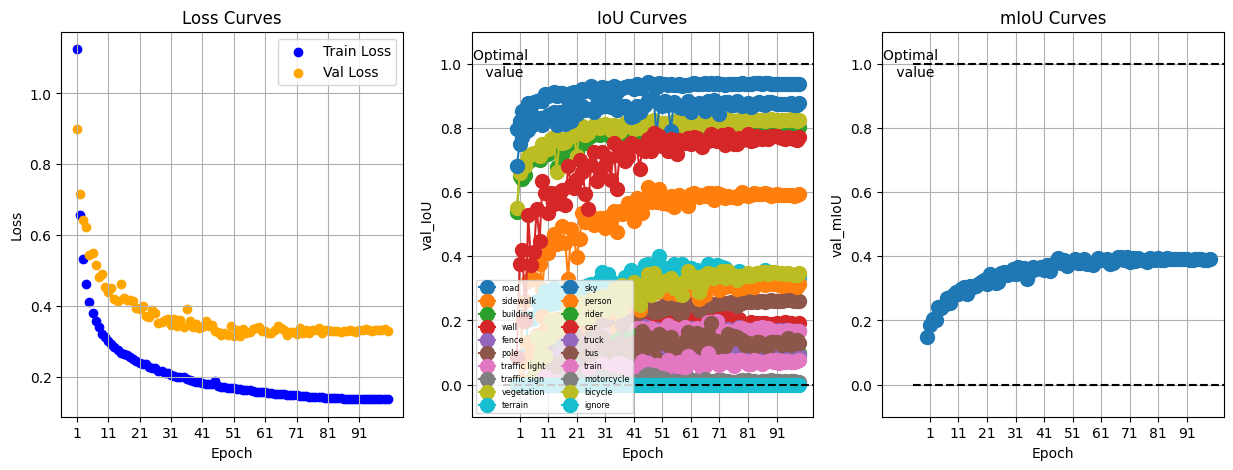

In [19]:
# Imprimir resultados do treinamento
if SCRIPT_MODE != "TEST":
    print_results(fit_model.results, metrics)
    best_results = get_best_results(fit_model.results, IoU_lables=ds_lables.id_names)

In [20]:
best_results

{'val_loss': 0.3312701339522997,
 'val_IoU': {'road': 0.9385415315628052,
  'sidewalk': 0.5945539474487305,
  'building': 0.8016156554222107,
  'wall': 0.19266366958618164,
  'fence': 0.16668720543384552,
  'pole': 0.26145294308662415,
  'traffic light': 0.16743285953998566,
  'traffic sign': 0.33132168650627136,
  'vegetation': 0.8236016035079956,
  'terrain': 0.3380031883716583,
  'sky': 0.8784523010253906,
  'person': 0.31400251388549805,
  'rider': 0.09974794089794159,
  'car': 0.7720087170600891,
  'truck': 0.09377685189247131,
  'bus': 0.12971952557563782,
  'train': 0.0775655210018158,
  'motorcycle': 0.009271620772778988,
  'bicycle': 0.3490146994590759,
  'ignore': 0.0},
 'val_mIoU': 0.3903897702693939}

## TESTAR MODELO SALVO

<Figure size 500x500 with 0 Axes>

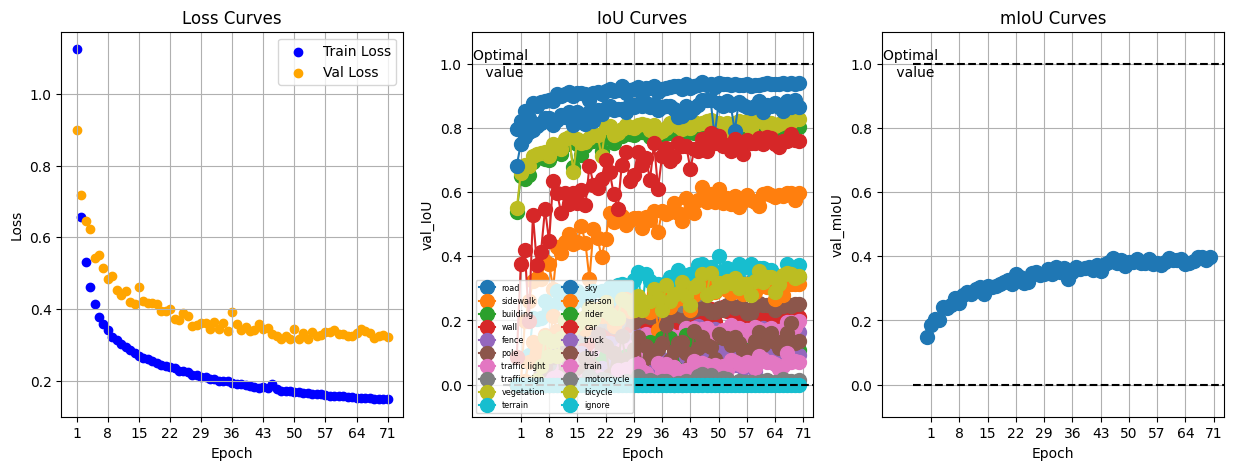

In [23]:
if SCRIPT_MODE != "TRAIN":

    # Criando novo modelo para carregar o salvo
    loaded_model = mb.FastSCNN(num_classes=NUM_CLASSES, aux=True).to(device)
    loaded_model = torch.compile(loaded_model) # Compila o modelo para melhorar a performance

    # Carregando apenas os parametros (state_dict()), pois isso flexibiliza o modelo e evita erros de incompatibilidade com parametros e caminhos do modelo original
    # OBS: torch.load() carrega o modelo inteiro, nao apenas os parametros
    loaded_model, loaded_model_results = load_state_dict(loaded_model, name="best_model", load_reults=True, device=device)
    
    # Imprimir os resultados
    print_results(loaded_model_results, metrics)
    best_loaded_results = get_best_results(loaded_model_results, IoU_lables=ds_lables.id_names)

In [24]:
best_loaded_results

{'val_loss': 0.3212999840577443,
 'val_IoU': {'road': 0.9396749138832092,
  'sidewalk': 0.5970247387886047,
  'building': 0.8029751777648926,
  'wall': 0.21069376170635223,
  'fence': 0.16255071759223938,
  'pole': 0.25133052468299866,
  'traffic light': 0.19741053879261017,
  'traffic sign': 0.33448103070259094,
  'vegetation': 0.8269854784011841,
  'terrain': 0.3724006712436676,
  'sky': 0.8650223016738892,
  'person': 0.31280532479286194,
  'rider': 0.10921436548233032,
  'car': 0.7598374485969543,
  'truck': 0.09357911348342896,
  'bus': 0.13727061450481415,
  'train': 0.07085682451725006,
  'motorcycle': 0.014799000695347786,
  'bicycle': 0.33944815397262573,
  'ignore': 0.0},
 'val_mIoU': 0.39795729517936707}

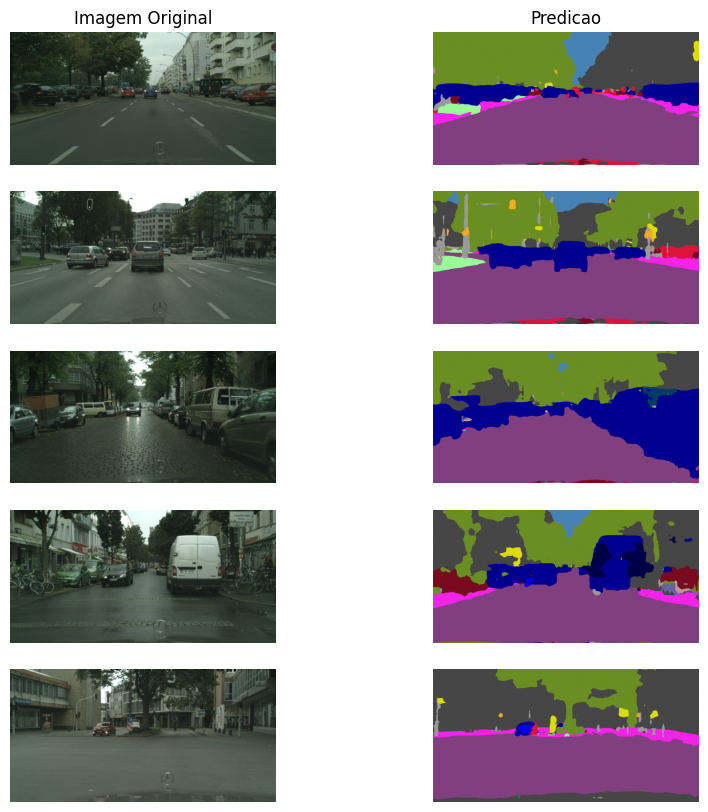

In [37]:
# Teste do modelo
test_model(loaded_model, test_dataset, n=5, device=device, cmap=cmap)


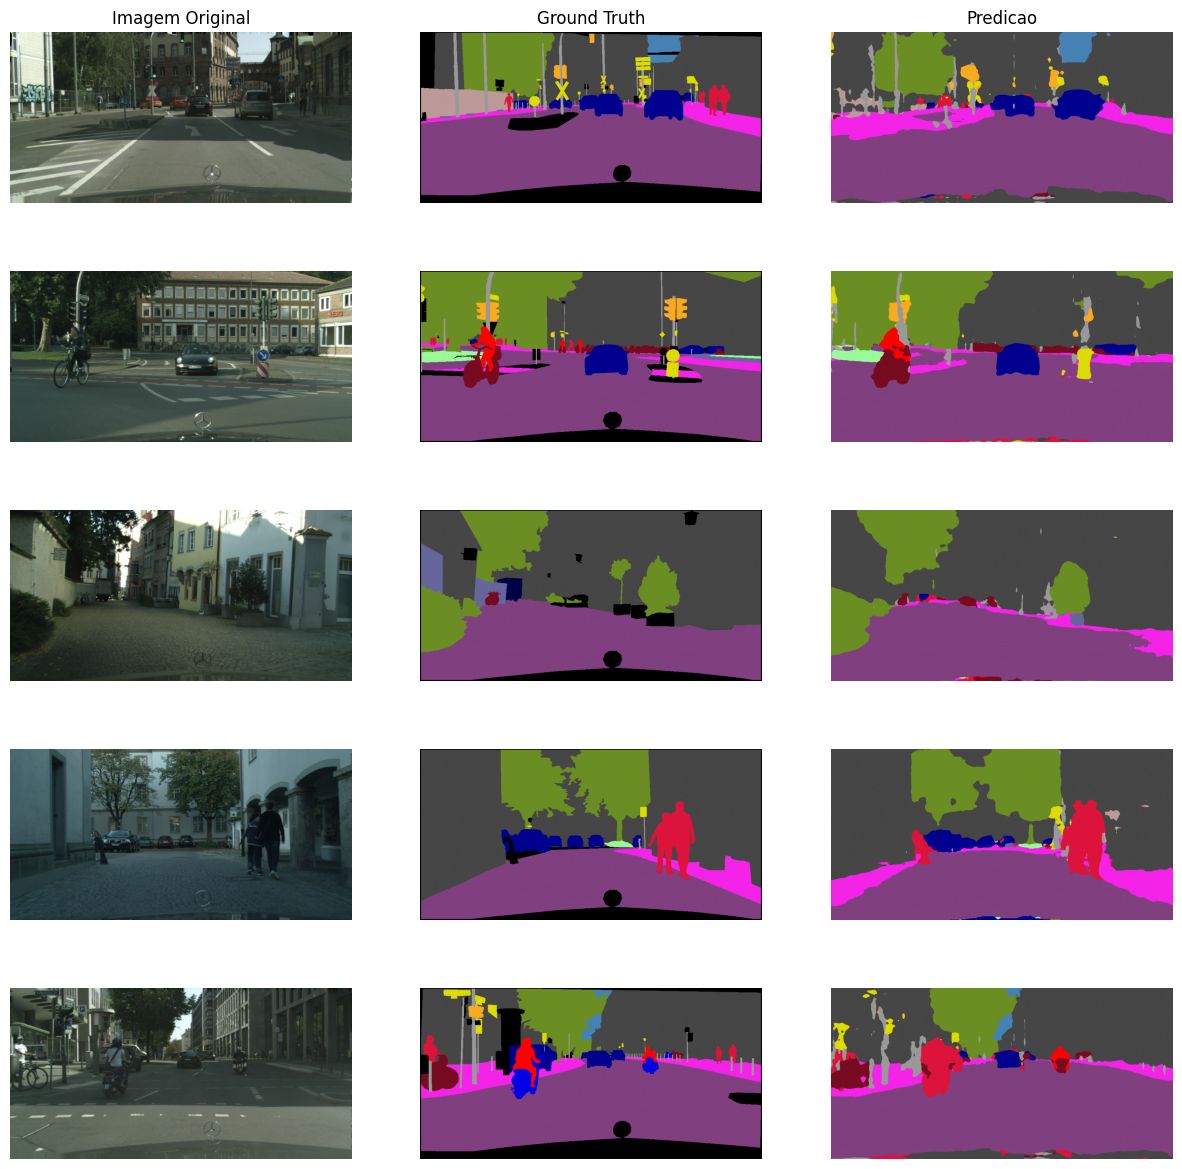

In [40]:
# Comparando mascaras verdadeirass com as mascaras preditas pelo modelo
dataset_show(val_dataset, n=5, predict_masks=True, model=loaded_model, device=device, cmap=cmap)

In [41]:
torch.cuda.empty_cache()